<a href="https://colab.research.google.com/github/gabrieldanho9988-sys/Project_Synthetic-Aperture-Radar-SAR-Super-Resolution-SR-using-AI-.ipynb/blob/main/Project_Synthetic_Aperture_Radar_(SAR)_Super_Resolution_(SR)_using_AI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_GEO_HH_20251112022441_20251112022453_preview.tif
Full image shape is: 46671x51171
Extracted patch max value: 255


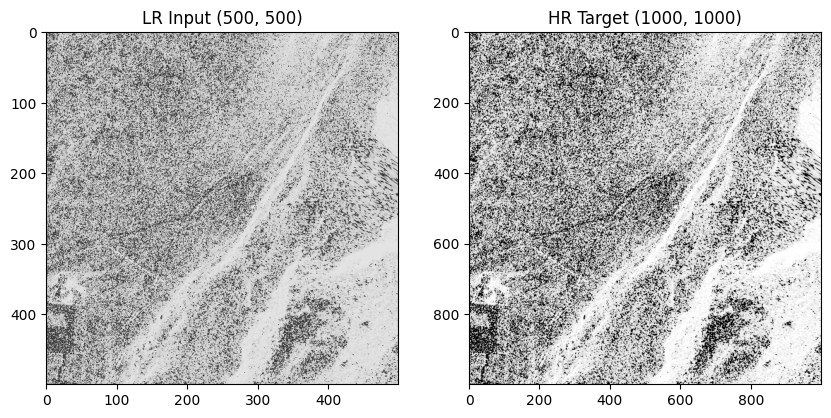

In [5]:
!pip install pystac stac-asset[cli] rasterio opencv-python matplotlib numpy nest-asyncio

import os
import pystac
import stac_asset.blocking
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt
import nest_asyncio

# 1. Fix the asyncio error in Colab
nest_asyncio.apply()

print("Downloading Capella STAC Catalog...")
collection_url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"
collection = pystac.Collection.from_file(collection_url)
item_links = collection.get_item_links()

# 2. Find the first GEO image
geo_item_link = None
for link in item_links:
    if "GEO" in link.absolute_href:
        geo_item_link = link.absolute_href
        break

print(f"Downloading GEO Item: {geo_item_link}")
item = pystac.Item.from_file(geo_item_link)

# 3. Filter out 'preview' and 'thumbnail' to get the REAL data asset (usually 'hh' or 'vv')
asset_key_to_download = None
for key, asset in item.assets.items():
    if asset.href.endswith('.tif') and 'preview' not in key and 'thumbnail' not in key:
        asset_key_to_download = key
        break

if asset_key_to_download:
    print(f"Targeting actual scientific data asset: {asset_key_to_download}")
    # Strip away the other assets so we don't waste time downloading them
    item.assets = {asset_key_to_download: item.assets[asset_key_to_download]}

os.makedirs("capella_data", exist_ok=True)

# 4. Download using the correct keyword 'directory'
print("Downloading... (This might take a minute depending on file size)")
item = stac_asset.blocking.download_item(item, directory="capella_data")

# Find the downloaded .tif file
tif_path = None
for root, dirs, files in os.walk("capella_data"):
    for file in files:
        if file.endswith(".tif"):
            tif_path = os.path.join(root, file)
            break

# 5. Preprocessing Functions
def preprocess_sar_image(raw_dn, scale_factor=0.00063784):
    epsilon = 1e-10
    dn_scaled = (raw_dn * scale_factor) + epsilon
    image_db = 20 * np.log10(dn_scaled)

    db_min, db_max = np.percentile(image_db, 2), np.percentile(image_db, 98)

    # Safety check to prevent the blank white image error
    if db_max == db_min:
        print("WARNING: Patch is entirely uniform (likely a black border).")
        return np.zeros_like(image_db)

    image_normalized = np.clip((image_db - db_min) / (db_max - db_min), 0, 1)
    return image_normalized

def create_hr_lr_pairs(hr_image, scale_factor_down=2):
    h, w = hr_image.shape
    new_h, new_w = h // scale_factor_down, w // scale_factor_down
    lr_image = cv2.resize(hr_image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    return hr_image, lr_image

# 6. Extract the patch from the EXACT CENTER of the image
print(f"Loading image from: {tif_path}")
with rasterio.open(tif_path) as src:
    height, width = src.shape
    print(f"Full image shape is: {height}x{width}")

    # Find the middle coordinates
    center_y, center_x = height // 2, width // 2
    patch_radius = 500  # Will create a 1000x1000 patch

    # Read just the central patch to save RAM
    real_raw_sar = src.read(1)[center_y - patch_radius : center_y + patch_radius,
                               center_x - patch_radius : center_x + patch_radius]

    print(f"Extracted patch max value: {np.max(real_raw_sar)}")

hr_target = preprocess_sar_image(real_raw_sar)
hr_target, lr_input = create_hr_lr_pairs(hr_target, scale_factor_down=2)

# 7. Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"LR Input {lr_input.shape}")
plt.imshow(lr_input, cmap='gray')
plt.subplot(1, 2, 2)
plt.title(f"HR Target {hr_target.shape}")
plt.imshow(hr_target, cmap='gray')
plt.show()